# Why Manual Tool Integration Doesn't Scale
## The N × M Problem — setting the stage for MCP

In the previous section, we built a working tool-use loop: an LLM that calls a weather function we defined. It works! So why do we need anything more?

In this notebook we'll deliberately try to **grow** what we just built and watch it fall apart. By the end you should feel the pain — and understand what kind of solution we need.

> **Goal of this lesson:** convince you that the approach we just used is not scalable, *before* we introduce MCP as the fix.

## Recap: what we built

Our weather assistant needed **four ingredients**:

| # | Ingredient | Role |
|---|---|---|
| 1 | A **tool function** (`get_weather_manual`) | The actual code that does the work |
| 2 | A **JSON schema** (`weather_tool_schema`) | Tells the LLM what the tool does and expects |
| 3 | A **dispatcher** (`if function_name == "get_weather": …`) | Routes the LLM's request to the right function |
| 4 | A **loop** (`chat_with_weather_tool`) | Orchestrates LLM ↔ tool ↔ LLM |

All four live inside **our application**. The LLM knows nothing about them until we manually wire them in on every request.

Keep that in mind — it will matter in a minute.

---
## Part 1: "What if we want more tools?" — the **M** dimension

A real assistant needs more than weather. Let's add four more tools:

- 📈 Stock prices
- 📅 Calendar events
- 🐛 GitHub issues
- 💬 Slack messages

Each new tool forces us to write **three things**: a function, a schema, and another branch in the dispatcher. Watch how quickly it bloats.

In [2]:
# ── 1. The tool functions (stubs — pretend they hit real APIs) ──

def get_weather(latitude, longitude):
    return {"temp_c": 22, "condition": "sunny"}

def get_stock_price(ticker):
    return {"ticker": ticker, "price_usd": 187.43}

def get_calendar_events(date):
    return {"date": date, "events": ["Team standup at 10:00"]}

def get_github_issues(repo):
    return {"repo": repo, "open_issues": 42}

def send_slack_message(channel, text):
    return {"status": "sent", "channel": channel, "text": text}


In [3]:
# ── 2. One JSON schema per tool (abbreviated for readability) ──

tools_schemas = [
    {
        "type": "function",
        "function": {
            "name": "get_weather",
            "description": "Get current weather for a lat/lon",
            "parameters": {
                "type": "object",
                "properties": {
                    "latitude":  {"type": "number"},
                    "longitude": {"type": "number"},
                },
                "required": ["latitude", "longitude"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "get_stock_price",
            "description": "Get the latest price for a stock ticker",
            "parameters": {
                "type": "object",
                "properties": {"ticker": {"type": "string"}},
                "required": ["ticker"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "get_calendar_events",
            "description": "Get the user's events for a given date",
            "parameters": {
                "type": "object",
                "properties": {"date": {"type": "string", "description": "YYYY-MM-DD"}},
                "required": ["date"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "get_github_issues",
            "description": "Get open issues for a GitHub repo",
            "parameters": {
                "type": "object",
                "properties": {"repo": {"type": "string", "description": "owner/repo"}},
                "required": ["repo"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "send_slack_message",
            "description": "Post a message to a Slack channel",
            "parameters": {
                "type": "object",
                "properties": {
                    "channel": {"type": "string"},
                    "text":    {"type": "string"},
                },
                "required": ["channel", "text"],
            },
        },
    },
]

print(f"We now maintain {len(tools_schemas)} schemas.")


We now maintain 5 schemas.


In [4]:
# ── 3. The dispatcher — this is where the pain really starts ──

def dispatch_tool_call(function_name, arguments):
    if function_name == "get_weather":
        return get_weather(**arguments)
    elif function_name == "get_stock_price":
        return get_stock_price(**arguments)
    elif function_name == "get_calendar_events":
        return get_calendar_events(**arguments)
    elif function_name == "get_github_issues":
        return get_github_issues(**arguments)
    elif function_name == "send_slack_message":
        return send_slack_message(**arguments)
    else:
        return {"error": f"Unknown tool: {function_name}"}

# Imagine this at 20 tools. At 50. At 200.


### 🔎 What just happened?

For **every new tool** we had to:

1. Write the function ✅ *(unavoidable — it's the actual work)*
2. Write a JSON schema *(duplicating info already in the Python signature)*
3. Add another `elif` branch to the dispatcher
4. Remember to include it in the `tools_schemas` list

And here's the bigger problem — **none of this is reusable.** If your teammate is also building an LLM app and wants GitHub access, they have to write all four pieces **again**, in their codebase.

There is no shared "here's how to call GitHub" module for LLMs. Everyone rebuilds it.

But it gets worse.

---
## Part 2: "What if we want to support a different LLM?" — the **N** dimension

Our code uses `client.chat.completions.create(...)` — that's **OpenAI's** API.

But our users might prefer Claude (Anthropic), or Gemini (Google), or a local Llama. Each provider has its **own** tool-calling format. Not slightly different. Fundamentally different.

Let's look at the *same* `get_weather` tool across three providers.

### 🟢 Schema format — how you *declare* the tool

In [5]:
# ── OpenAI ──
openai_tool = {
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get current weather",
        "parameters": {
            "type": "object",
            "properties": {
                "latitude":  {"type": "number"},
                "longitude": {"type": "number"},
            },
            "required": ["latitude", "longitude"],
        },
    },
}

# ── Anthropic ──  (flatter, "input_schema" not "parameters")
anthropic_tool = {
    "name": "get_weather",
    "description": "Get current weather",
    "input_schema": {
        "type": "object",
        "properties": {
            "latitude":  {"type": "number"},
            "longitude": {"type": "number"},
        },
        "required": ["latitude", "longitude"],
    },
}

# ── Google Gemini ──  (wrapped in "function_declarations")
gemini_tool = {
    "function_declarations": [{
        "name": "get_weather",
        "description": "Get current weather",
        "parameters": {
            "type": "object",
            "properties": {
                "latitude":  {"type": "number"},
                "longitude": {"type": "number"},
            },
            "required": ["latitude", "longitude"],
        },
    }],
}


### 🟡 Response parsing — how you *detect* a tool call

In [6]:
# ── OpenAI ──
# msg = response.choices[0].message
# if msg.tool_calls:
#     for tc in msg.tool_calls:
#         name = tc.function.name
#         args = json.loads(tc.function.arguments)     # ← a JSON STRING
#         call_id = tc.id

# ── Anthropic ──
# for block in response.content:
#     if block.type == "tool_use":
#         name = block.name
#         args = block.input                            # ← already a DICT
#         call_id = block.id

# ── Google Gemini ──
# for part in response.candidates[0].content.parts:
#     if part.function_call:
#         name = part.function_call.name
#         args = dict(part.function_call.args)
#         # no call_id at all — Gemini matches by position


### 🔴 Sending the tool result back — three different shapes

In [7]:
# ── OpenAI — a dedicated "tool" role ──
# messages.append({
#     "role": "tool",
#     "tool_call_id": tc.id,
#     "content": json.dumps(result),
# })

# ── Anthropic — a "user" message containing a tool_result block ──
# messages.append({
#     "role": "user",
#     "content": [{
#         "type": "tool_result",
#         "tool_use_id": block.id,
#         "content": json.dumps(result),
#     }],
# })

# ── Gemini — a "function" role, no id, result lives under function_response ──
# contents.append({
#     "role": "function",
#     "parts": [{"function_response": {"name": name, "response": result}}],
# })


### 🔎 The differences pile up

Between OpenAI, Anthropic, and Gemini, the following are all different:

- **Schema shape** — nested vs flat, `parameters` vs `input_schema`, wrapper keys
- **Where tool calls live in the response** — `choices[0].message.tool_calls` vs `content` blocks vs `candidates[0].content.parts`
- **Argument encoding** — JSON string vs dict
- **How you return the result** — `role: "tool"` vs `role: "user"` with a special block vs `role: "function"`
- **Whether there's a `call_id`** at all
- **Streaming, parallel tool calls, error semantics** — all subtly different

So to support 3 providers, we don't just translate 3 schemas — we rewrite the **entire loop** 3 times. And for every new tool we add, we now repeat the wiring work **per provider**.

---
## Part 3: The N × M explosion

Let's count the integration work honestly.

- **N** = number of LLM clients / applications *(ChatGPT, Claude Desktop, Cursor, your app, your coworker's app, the IDE plugin, the Slack bot, …)*
- **M** = number of tools / data sources *(weather, GitHub, Slack, Notion, Postgres, Gmail, Stripe, Jira, …)*

Without any standard, **every (client, tool) pair needs its own custom integration**.

$$\text{Total integrations} = N \times M$$

Let's visualize it.

In [8]:
import pandas as pd

clients = ["ChatGPT", "Claude Desktop", "Cursor", "Your App", "Coworker's Bot"]
tools   = ["Weather", "GitHub", "Slack", "Notion", "Postgres", "Gmail", "Calendar", "Stripe"]

N, M = len(clients), len(tools)

matrix = pd.DataFrame(
    [["🔧 custom integration"] * M for _ in clients],
    index=clients,
    columns=tools,
)

print(f"N = {N} clients")
print(f"M = {M} tools")
print(f"Integrations to build and maintain: {N} × {M} = {N * M}")
print()
matrix


N = 5 clients
M = 8 tools
Integrations to build and maintain: 5 × 8 = 40



,Weather,GitHub,Slack,Notion,Postgres,Gmail,Calendar,Stripe
ChatGPT,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration
Claude Desktop,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration
Cursor,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration
Your App,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration
Coworker's Bot,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration,🔧 custom integration


### 📈 The growth is multiplicative

- Add **one new tool**? Every existing client must integrate it → **+N work**
- Add **one new client/app**? It must re-integrate every existing tool → **+M work**
- Every integration needs **ongoing maintenance** — API changes, auth rotations, bug fixes, new fields
- There is **no discovery** — tools can't announce themselves to clients at runtime; everything is hardcoded and shipped with the app

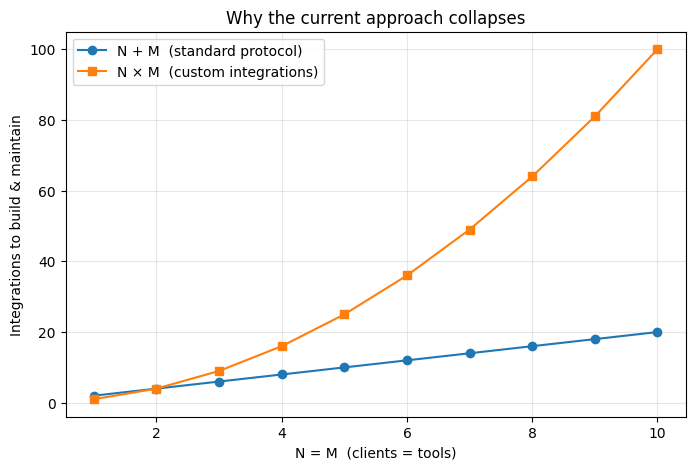

In [9]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1, 11)  # 1..10
plt.figure(figsize=(8, 5))
plt.plot(x, x + x,   marker="o", label="N + M  (standard protocol)")
plt.plot(x, x * x,   marker="s", label="N × M  (custom integrations)")
plt.xlabel("N = M  (clients = tools)")
plt.ylabel("Integrations to build & maintain")
plt.title("Why the current approach collapses")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


At 10 clients and 10 tools that's **100 integrations vs 20**. At 50 and 50, it's **2,500 vs 100**.

This is exactly why, as of a couple of years ago, almost no LLM-powered app had deep access to your real tools. The integration tax was simply too high.

---
## Part 4: What we want instead

We want a **standard protocol** such that:

- Anyone with a tool writes a small **server** exposing it — **once**. *(M servers)*
- Anyone building an app writes a **client** that speaks the protocol — **once**. *(N clients)*
- Any compliant client can talk to any compliant server.
- Tools become **discoverable at runtime** — no hardcoding, no recompiling to add a tool.

$$\text{Integrations} : N \times M \;\longrightarrow\; N + M$$

This is exactly the same lesson as:

- **USB** — before it, every peripheral had its own port. After it, one plug fits all.
- **LSP (Language Server Protocol)** — before it, every editor × every language needed custom support. After it, editors and language servers pair freely.
- **HTTP** — before it, every network app invented its own wire format.

The protocol we're going to learn next solves this for LLMs and tools. It's called **Model Context Protocol** — **MCP**.

👉 *Next lesson: what MCP actually is, and how the same weather example looks under it.*